# Task 1: Inner Workings of ResNet-152

1. Baseline Setup

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [10]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
transform_val = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train
)
val_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val
)

rng = np.random.default_rng(42)

train_indices = rng.choice(len(train_dataset), size=len(train_dataset) // 2, replace=False)
val_indices   = rng.choice(len(val_dataset),   size=len(val_dataset)   // 2, replace=False)

train_dataset = Subset(train_dataset, train_indices)
val_dataset   = Subset(val_dataset,   val_indices)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)
 
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
 
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {CIFAR10_CLASSES}")

100%|██████████| 170M/170M [14:58<00:00, 190kB/s] 


Training samples: 25000
Validation samples: 5000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [11]:
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
num_features = model.fc.in_features
print()
print(f"ResNet-152 feature vector size (2048): {num_features}")
model.fc = nn.Linear(num_features, 10)
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  "
      f"({100.0 * trainable_params / total_params:.4f}%)")


ResNet-152 feature vector size (2048): 2048
Total parameters: 58,164,298
Trainable parameters: 20,490  (0.0352%)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one full pass over the training set. Returns avg loss and accuracy."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
 
    for (inputs, labels) in tqdm(loader, desc='Training'):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
 
    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy
 
 
def validate(model, loader, criterion, device):
    """Run one full pass over the validation set. Returns avg loss and accuracy."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
 
    with torch.no_grad():
        for (inputs, labels) in tqdm(loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
 
    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [ ]:
NUM_EPOCHS = 5
train_losses, train_accs = [], []
val_losses, val_accs = [], []
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*55}")
    print(f"  Epoch {epoch + 1} / {NUM_EPOCHS}")
    print('='*55)
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = validate(model, val_loader, criterion, device)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(vl_loss); val_accs.append(vl_acc)
    print()
    print(f"  → Train      | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2f}%")
    print(f"  → Validation | Loss: {vl_loss:.4f} | Acc: {vl_acc:.2f}%")


  Epoch 1 / 5


Validating: 100%|██████████| 79/79 [00:40<00:00,  1.96it/s]



  → Train  | Loss: 0.7751 | Acc: 75.37%
  → Validation   | Loss: 0.5409 | Acc: 81.20%

  Epoch 2 / 5


Validating: 100%|██████████| 79/79 [00:40<00:00,  1.95it/s]



  → Train  | Loss: 0.5506 | Acc: 81.29%
  → Validation   | Loss: 0.5557 | Acc: 80.78%

  Epoch 3 / 5


...


  → Train  | Loss: 0.5197 | Acc: 82.10%
  → Validation   | Loss: 0.4822 | Acc: 83.34%

  Epoch 4 / 5


Validating: 100%|██████████| 79/79 [00:40<00:00,  1.97it/s]



  → Train  | Loss: 0.5066 | Acc: 82.53%
  → Validation   | Loss: 0.4953 | Acc: 82.88%

  Epoch 5 / 5


Validating: 100%|██████████| 79/79 [00:39<00:00,  1.98it/s]


  → Train  | Loss: 0.4964 | Acc: 82.65%
  → Validation   | Loss: 0.5079 | Acc: 82.62%


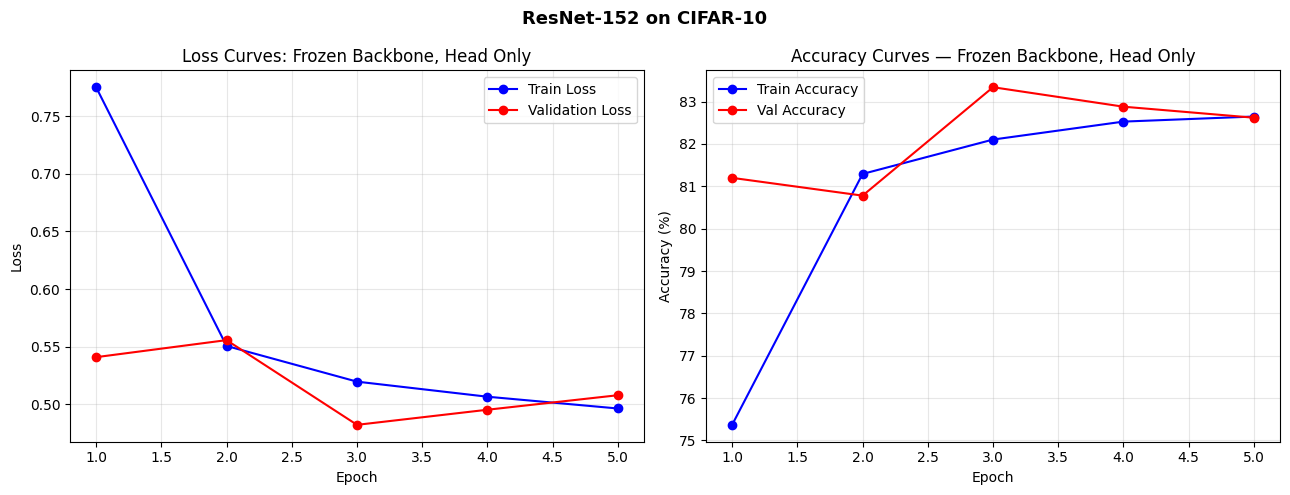

In [15]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss plot
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves: Frozen Backbone, Head Only')
ax1.legend()
ax1.grid(True, alpha=0.3)
 
# Accuracy plot
ax2.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs, val_accs, 'r-o', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves — Frozen Backbone, Head Only')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-152 on CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Final Summary
print("\n===== Final Results Summary =====")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Val Loss':<14} {'Val Acc'}")
print("-" * 60)
for i, (tl, ta, vl, va) in enumerate(zip(train_losses, train_accs, val_losses, val_accs), 1):
    print(f"{i:<8} {tl:<14.4f} {ta:<14.2f} {vl:<14.4f} {va:.2f}")
print(f"\nBest Val Accuracy: {max(val_accs):.2f}% at Epoch {val_accs.index(max(val_accs))+1}")


===== Final Results Summary =====
Epoch    Train Loss     Train Acc      Val Loss       Val Acc
------------------------------------------------------------
1        0.7751         75.37          0.5409         81.20
2        0.5506         81.29          0.5557         80.78
3        0.5197         82.10          0.4822         83.34
4        0.5066         82.53          0.4953         82.88
5        0.4964         82.65          0.5079         82.62

Best Val Accuracy: 83.34% at Epoch 3


Task 1.2: Residual Connections in Practice

In [17]:
import types

In [18]:
# ── 1. Custom forward with skip connection removed ────────────────────────────

def bottleneck_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)
    out = self.relu(out)   # relu applied directly — no identity added
    return out

In [19]:
# ── 2. Fresh pretrained ResNet-152 ───────────────────────────────────────────

model_no_skip = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

for param in model_no_skip.parameters():
    param.requires_grad = False

model_no_skip.fc = nn.Linear(model_no_skip.fc.in_features, 10)
model_no_skip = model_no_skip.to(device)

In [20]:
# ── 3. Patch selected blocks in layer4 ───────────────────────────────────────
# We target layer4 because it's the deepest and most semantically rich stage
# — disabling skips here has the most visible impact on gradient flow

target_blocks = [
    model_no_skip.layer4[0],
    model_no_skip.layer4[1],
]

for block in target_blocks:
    block.forward = types.MethodType(bottleneck_no_skip, block)

print("Skip connections disabled in layer4[0] and layer4[1]")

Skip connections disabled in layer4[0] and layer4[1]


In [21]:
# ── 4. Optimizer ──────────────────────────────────────────────────────────────

criterion_no_skip = nn.CrossEntropyLoss()
optimizer_no_skip = optim.Adam(model_no_skip.fc.parameters(), lr=1e-3)

In [22]:
# ── 5. Train ──────────────────────────────────────────────────────────────────

NUM_EPOCHS = 5
train_losses_no_skip, train_accs_no_skip = [], []
val_losses_no_skip,   val_accs_no_skip   = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*55}")
    print(f"  Epoch {epoch + 1} / {NUM_EPOCHS}  [No Skip Connections]")
    print('='*55)

    tr_loss, tr_acc = train_one_epoch(model_no_skip, train_loader,
                                      optimizer_no_skip, criterion_no_skip, device)
    vl_loss, vl_acc = validate(model_no_skip, val_loader,
                               criterion_no_skip, device)

    train_losses_no_skip.append(tr_loss)
    train_accs_no_skip.append(tr_acc)
    val_losses_no_skip.append(vl_loss)
    val_accs_no_skip.append(vl_acc)

    print(f"  → Train      | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2f}%")
    print(f"  → Validation | Loss: {vl_loss:.4f} | Acc: {vl_acc:.2f}%")


  Epoch 1 / 5  [No Skip Connections]


Validating: 100%|██████████| 79/79 [00:39<00:00,  1.98it/s]


  → Train      | Loss: 1.1142 | Acc: 65.58%
  → Validation | Loss: 0.8170 | Acc: 72.96%

  Epoch 2 / 5  [No Skip Connections]


Validating: 100%|██████████| 79/79 [00:39<00:00,  1.99it/s]


  → Train      | Loss: 0.8226 | Acc: 72.22%
  → Validation | Loss: 0.7815 | Acc: 73.42%

  Epoch 3 / 5  [No Skip Connections]


...

  → Train      | Loss: 0.7812 | Acc: 73.26%
  → Validation | Loss: 0.7573 | Acc: 73.92%

  Epoch 4 / 5  [No Skip Connections]


Validating: 100%|██████████| 79/79 [00:39<00:00,  2.00it/s]


  → Train      | Loss: 0.7510 | Acc: 74.22%
  → Validation | Loss: 0.7298 | Acc: 74.36%

  Epoch 5 / 5  [No Skip Connections]


Validating: 100%|██████████| 79/79 [00:39<00:00,  1.99it/s]

  → Train      | Loss: 0.7316 | Acc: 74.98%
  → Validation | Loss: 0.7259 | Acc: 74.54%


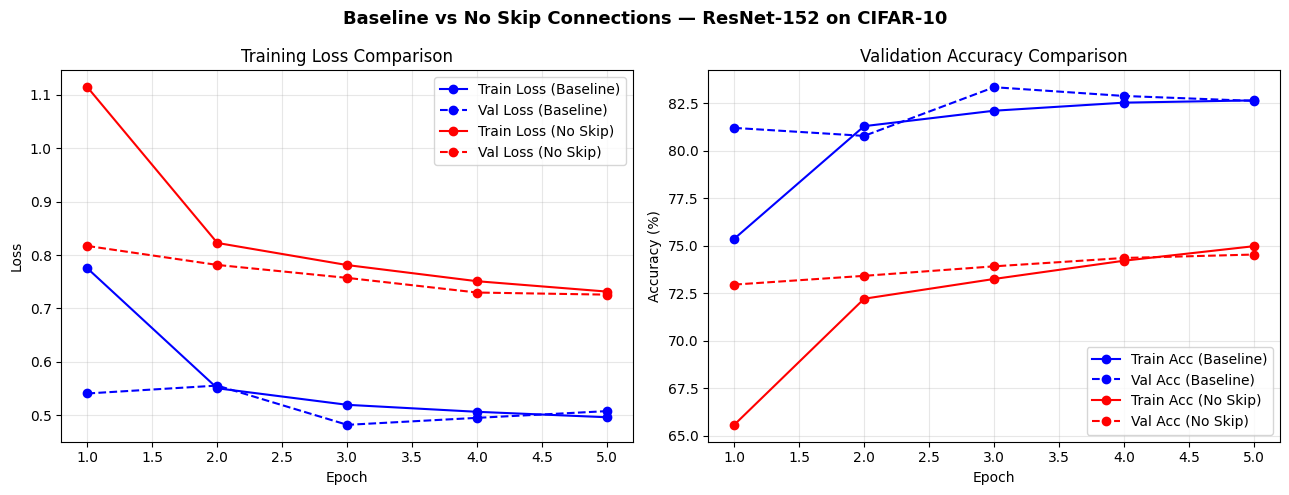

In [23]:
# ── 6. Compare against baseline ───────────────────────────────────────────────

epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, train_losses,         'b-o',  label='Train Loss (Baseline)')
ax1.plot(epochs, val_losses,           'b--o', label='Val Loss (Baseline)')
ax1.plot(epochs, train_losses_no_skip, 'r-o',  label='Train Loss (No Skip)')
ax1.plot(epochs, val_losses_no_skip,   'r--o', label='Val Loss (No Skip)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs,         'b-o',  label='Train Acc (Baseline)')
ax2.plot(epochs, val_accs,           'b--o', label='Val Acc (Baseline)')
ax2.plot(epochs, train_accs_no_skip, 'r-o',  label='Train Acc (No Skip)')
ax2.plot(epochs, val_accs_no_skip,   'r--o', label='Val Acc (No Skip)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Baseline vs No Skip Connections — ResNet-152 on CIFAR-10',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_skip_connections.png', dpi=150, bbox_inches='tight')
plt.show()

Task 1.3: Feature Heirarchies and Representations

In [24]:
from sklearn.manifold import TSNE

In [25]:
# ── 1. Hook infrastructure ────────────────────────────────────────────────────
feature_store = {}

def make_hook(name):
    def hook(module, input, output):
        # output is (batch, channels, H, W) — global average pool to (batch, channels)
        feature_store[name] = output.mean(dim=[2, 3]).detach().cpu()
    return hook

In [26]:
# ── 2. Register hooks on early, middle, late layers ──────────────────────────
# We use the baseline model from Task 1.1

hooks = [
    model.layer1.register_forward_hook(make_hook('layer1')),  # early
    model.layer2.register_forward_hook(make_hook('layer2')),  # mid-early
    model.layer3.register_forward_hook(make_hook('layer3')),  # mid-late
    model.layer4.register_forward_hook(make_hook('layer4')),  # late
]

In [27]:
# ── 3. Extract features over validation set ───────────────────────────────────

all_features = {name: [] for name in ['layer1', 'layer2', 'layer3', 'layer4']}
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Extracting features'):
        inputs = inputs.to(device)
        _ = model(inputs)   # forward pass triggers hooks
        for name in all_features:
            all_features[name].append(feature_store[name])
        all_labels.append(labels)

# Remove hooks after use — important, otherwise they stack up
for hook in hooks:
    hook.remove()

# Concatenate into single tensors
for name in all_features:
    all_features[name] = torch.cat(all_features[name], dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print("Feature shapes:")
for name, feat in all_features.items():
    print(f"  {name}: {feat.shape}")

Extracting features: 100%|██████████| 79/79 [00:41<00:00,  1.90it/s]

Feature shapes:
  layer1: (5000, 256)
  layer2: (5000, 512)
  layer3: (5000, 1024)
  layer4: (5000, 2048)


Running t-SNE on layer1...
Running t-SNE on layer2...
Running t-SNE on layer3...
Running t-SNE on layer4...


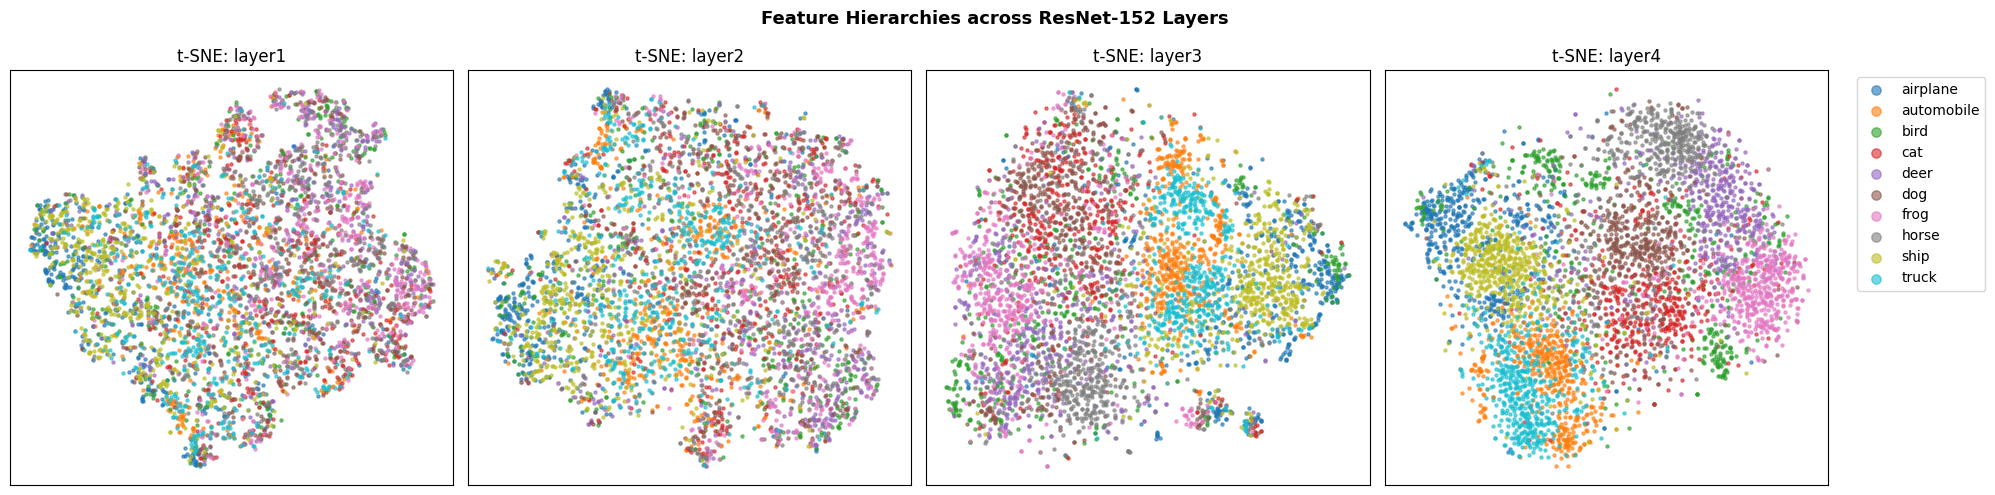

In [29]:
# ── 4. t-SNE and plotting ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
layer_names = ['layer1', 'layer2', 'layer3', 'layer4']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, name in zip(axes, layer_names):
    print(f"Running t-SNE on {name}...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    embedded = tsne.fit_transform(all_features[name])

    for cls_idx, cls_name in enumerate(CIFAR10_CLASSES):
        mask = all_labels == cls_idx
        ax.scatter(embedded[mask, 0], embedded[mask, 1],
                   c=[colors[cls_idx]], label=cls_name,
                   s=5, alpha=0.6)

    ax.set_title(f't-SNE: {name}')
    ax.set_xticks([])
    ax.set_yticks([])

axes[-1].legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('Feature Hierarchies across ResNet-152 Layers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_feature_hierarchies.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── 1. Helper to build a model under each strategy ───────────────────────────
def build_model(strategy, device):
    """
    strategy: 'head_only' | 'last_block' | 'full_backbone' | 'random_init'
    """
    if strategy == 'random_init':
        model = models.resnet152(weights=None)   # no pretrained weights
    else:
        model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

    # Replace head for CIFAR-10
    model.fc = nn.Linear(model.fc.in_features, 10)

    if strategy == 'head_only':
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    elif strategy == 'last_block':
        for name, param in model.named_parameters():
            if 'fc' not in name and 'layer4' not in name:
                param.requires_grad = False

    elif strategy in ('full_backbone', 'random_init'):
        pass   # all parameters trainable by default

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  [{strategy}] Trainable: {trainable:,} / {total:,} "
          f"({100.0 * trainable / total:.2f}%)")

    return model.to(device)


# ── 2. Helper to build optimizer per strategy ─────────────────────────────────
def build_optimizer(model, strategy):
    """
    Use a higher lr for the head and lower lr for backbone layers
    to avoid destroying pretrained features.
    """
    if strategy in ('head_only', 'last_block'):
        return optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
        )
    elif strategy == 'full_backbone':
        return optim.Adam([
            {'params': model.fc.parameters(),     'lr': 1e-3},
            {'params': model.layer4.parameters(), 'lr': 1e-4},
            {'params': list(model.layer1.parameters()) +
                       list(model.layer2.parameters()) +
                       list(model.layer3.parameters()), 'lr': 1e-5},
        ])
    elif strategy == 'random_init':
        return optim.Adam(model.parameters(), lr=1e-3)

In [31]:
# ── 3. Train all four strategies ──────────────────────────────────────────────

NUM_EPOCHS = 5
strategies = ['head_only', 'last_block', 'full_backbone', 'random_init']
results = {}   # stores {strategy: {train_losses, val_losses, train_accs, val_accs}}

# head_only results already exist from Task 1.1 — reuse them
results['head_only'] = {
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'train_accs':   train_accs,
    'val_accs':     val_accs,
}

for strategy in ['last_block', 'full_backbone', 'random_init']:
    print(f"\n{'='*55}")
    print(f"  Strategy: {strategy}")
    print('='*55)

    m   = build_model(strategy, device)
    opt = build_optimizer(m, strategy)
    crit = nn.CrossEntropyLoss()

    tr_losses, tr_accs = [], []
    vl_losses, vl_accs = [], []

    for epoch in range(NUM_EPOCHS):
        print(f"\n  Epoch {epoch + 1} / {NUM_EPOCHS}")
        tr_loss, tr_acc = train_one_epoch(m, train_loader, opt, crit, device)
        vl_loss, vl_acc = validate(m, val_loader, crit, device)

        tr_losses.append(tr_loss); tr_accs.append(tr_acc)
        vl_losses.append(vl_loss); vl_accs.append(vl_acc)

        print(f"  → Train      | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2f}%")
        print(f"  → Validation | Loss: {vl_loss:.4f} | Acc: {vl_acc:.2f}%")

    results[strategy] = {
        'train_losses': tr_losses,
        'val_losses':   vl_losses,
        'train_accs':   tr_accs,
        'val_accs':     vl_accs,
    }


  Strategy: last_block
  [last_block] Trainable: 14,985,226 / 58,164,298 (25.76%)

  Epoch 1 / 5


Validating: 100%|██████████| 79/79 [00:40<00:00,  1.95it/s]


  → Train      | Loss: 0.4825 | Acc: 83.85%
  → Validation | Loss: 0.3382 | Acc: 88.80%

  Epoch 2 / 5


Validating: 100%|██████████| 79/79 [00:40<00:00,  1.96it/s]


  → Train      | Loss: 0.2737 | Acc: 90.78%
  → Validation | Loss: 0.3023 | Acc: 89.40%

  Epoch 3 / 5


...

  → Train      | Loss: 1.3818 | Acc: 49.47%
  → Validation | Loss: 1.3598 | Acc: 51.96%

  Epoch 4 / 5


Validating: 100%|██████████| 79/79 [00:41<00:00,  1.92it/s]


  → Train      | Loss: 1.1616 | Acc: 57.87%
  → Validation | Loss: 1.3002 | Acc: 54.32%

  Epoch 5 / 5


Validating: 100%|██████████| 79/79 [00:41<00:00,  1.92it/s]

  → Train      | Loss: 0.9944 | Acc: 64.40%
  → Validation | Loss: 1.1233 | Acc: 62.50%


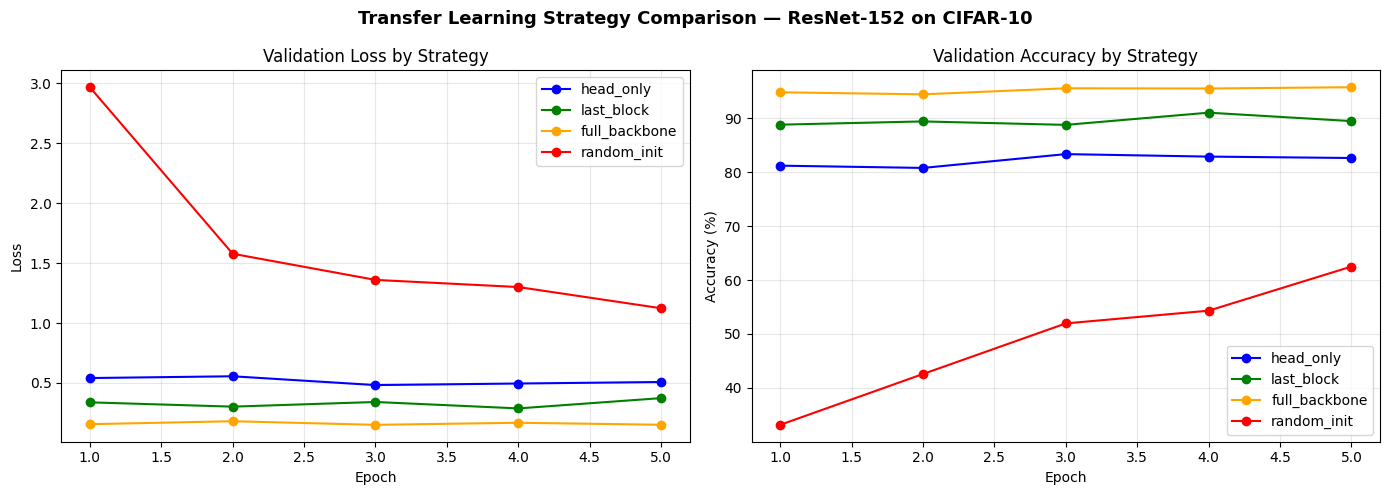

In [32]:
# ── 4. Plot comparison ────────────────────────────────────────────────────────

epochs = range(1, NUM_EPOCHS + 1)
colors = {'head_only': 'blue', 'last_block': 'green',
          'full_backbone': 'orange', 'random_init': 'red'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for strategy, res in results.items():
    ax1.plot(epochs, res['val_losses'], '-o',
             color=colors[strategy], label=strategy)
    ax2.plot(epochs, res['val_accs'],  '-o',
             color=colors[strategy], label=strategy)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss by Strategy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy by Strategy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Transfer Learning Strategy Comparison — ResNet-152 on CIFAR-10',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── 5. Final accuracy summary table ──────────────────────────────────────────

print("\n===== Final Validation Accuracy Summary =====")
print(f"{'Strategy':<20} {'Best Val Acc':>15}")
print("-" * 37)
for strategy, res in results.items():
    best = max(res['val_accs'])
    print(f"{strategy:<20} {best:>14.2f}%")


===== Final Validation Accuracy Summary =====
Strategy                Best Val Acc
-------------------------------------
head_only                     83.34%
last_block                    91.02%
full_backbone                 95.74%
random_init                   62.50%
